## **FineTuning**

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

# model, tokenizer = FastVisionModel.from_pretrained(
#     "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
#     load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
#     use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
# )

model, tokenizer = FastVisionModel.from_pretrained(
    "Abdullah-123/qwen2vl-2b-hrvqa-lora",  # your saved weights
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.4: Fast Qwen2_Vl patching. Transformers: 4.57.1.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,  # finetune the vision encoder
    finetune_language_layers   = True,  # finetune the language decoder
    finetune_attention_modules = True,  # finetune attention layers
    finetune_mlp_modules       = True,  # finetune MLP layers

    r            = 16,    # LoRA rank — higher = more capacity but may overfit
    lora_alpha   = 16,    # recommended: lora_alpha == r
    lora_dropout = 0,
    bias         = "none",
    random_state = 3407,
    use_rslora   = False,
    loftq_config = None,
)

In [ ]:
!git clone https://huggingface.co/datasets/JNIC1/HRVQA

Cloning into 'HRVQA'...
remote: Enumerating objects: 10134, done.
remote: Total 10134 (delta 0), reused 0 (delta 0), pack-reused 10134 (from 1)
Receiving objects: 100% (10134/10134), 1.93 MiB | 6.25 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Updating files: 100% (10006/10006), done.
Filtering content: 100% (10003/10003), 15.74 GiB | 178.99 MiB/s, done.


In [ ]:
import os
images=[]

for img in os.listdir("/content/HRVQA/images"):
  images.append(img)
  # image = f"/content/HRVQA/images{img}".split(".")[0]
  # images.append(image)
len(images)

In [ ]:
images[:10]

['4891.png',
 '7615.png',
 '2740.png',
 '7310.png',
 '4504.png',
 '9397.png',
 '8798.png',
 '1799.png',
 '2056.png',
 '998.png']

In [ ]:
import json

with open("/content/filtered_questions.json", "r") as f:
  questions = json.load(f)

with open("/content/filtered_answers.json", "r") as f:
  answers = json.load(f)

In [ ]:
questions[0]

{'image_id': 1,
 'question': 'What is the main transportation of this image?',
 'question_id': 0,
 'image_name': '2021_131000_460000_RGB_hrl_0_0',
 'question_type': 'transportation'}

In [ ]:
answers[0]

{'multiple_choice_answer': 'car', 'question_id': 0}

### Custom Train-Validation-Test Split
To achieve the desired split of 7999 training images, 1000 validation images, and 1000 test images, we will perform a two-step splitting process based on unique `image_id`s. This ensures that all question-answer pairs related to the same image remain in a single dataset (train, validation, or test) to prevent data leakage.

1.  **Combine Questions and Answers**: As before, merge the `questions` and `answers` into a single DataFrame (`df_qa`).
2.  **Extract Unique Image IDs**: Get all unique `image_id`s from `df_qa`.
3.  **Initial Split (Train vs. Temp Val/Test)**: Split the unique image IDs into two groups:
    *   `train_image_ids`: Contains 7999 image IDs for the training set.
    *   `temp_val_test_image_ids`: Contains the remaining 2000 image IDs (for validation and testing).
4.  **Second Split (Validation vs. Test)**: Split `temp_val_test_image_ids` into:
    *   `validation_image_ids`: Contains 1000 image IDs for the validation set.
    *   `test_image_ids`: Contains 1000 image IDs for the test set.
5.  **Create Datasets**: Filter `df_qa` using these split image IDs to form `train_dataset`, `validation_dataset`, and `test_dataset`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Combine questions and answers into a DataFrame
answers_by_question_id = {ans['question_id']: ans['multiple_choice_answer'] for ans in answers}
combined_data = []
for q_entry in questions:
    question_id = q_entry['question_id']
    if question_id in answers_by_question_id:
        combined_data.append({
            'question_id': question_id,
            'image_id': q_entry['image_id'],
            'question': q_entry['question'],
            'image_name_from_question': q_entry['image_name'],
            'question_type': q_entry['question_type'],
            'answer': answers_by_question_id[question_id]
        })
df_qa = pd.DataFrame(combined_data)

# 2. Get all unique image IDs
unique_image_ids = df_qa['image_id'].unique()

# Desired counts
N_TRAIN_IMAGES = 7999
N_VAL_IMAGES = 1000
N_TEST_IMAGES = 1000
TOTAL_UNIQUE_IMAGES = len(unique_image_ids)

if N_TRAIN_IMAGES + N_VAL_IMAGES + N_TEST_IMAGES != TOTAL_UNIQUE_IMAGES:
    raise ValueError("Desired split counts do not sum up to total unique images.")

# 3. Initial Split: Train vs. Temp Val/Test
temp_val_test_size = (N_VAL_IMAGES + N_TEST_IMAGES) / TOTAL_UNIQUE_IMAGES
train_image_ids, temp_val_test_image_ids = train_test_split(
    unique_image_ids, test_size=temp_val_test_size, random_state=42
)

# Ensure the train_image_ids count is correct
# Due to floating point precision in test_size, sometimes the split might be off by 1.
# We adjust by taking a slice if necessary to get the exact count.
if len(train_image_ids) != N_TRAIN_IMAGES:
    # If the initial split didn't yield exactly N_TRAIN_IMAGES due to rounding,
    # we adjust by either taking more from temp_val_test_image_ids or giving back.
    current_train_count = len(train_image_ids)
    if current_train_count > N_TRAIN_IMAGES:
        # Too many in train, move excess to temp_val_test
        excess = current_train_count - N_TRAIN_IMAGES
        temp_val_test_image_ids = list(temp_val_test_image_ids) + list(train_image_ids[-excess:])
        train_image_ids = train_image_ids[:-excess]
    else:
        # Too few in train, take from temp_val_test
        needed = N_TRAIN_IMAGES - current_train_count
        train_image_ids = list(train_image_ids) + list(temp_val_test_image_ids[:needed])
        temp_val_test_image_ids = temp_val_test_image_ids[needed:]

# Convert back to numpy array for consistency
train_image_ids = pd.Series(train_image_ids).unique()
temp_val_test_image_ids = pd.Series(temp_val_test_image_ids).unique()

# 4. Second Split: Validation vs. Test from temp_val_test_image_ids
val_test_split_size = N_TEST_IMAGES / (N_VAL_IMAGES + N_TEST_IMAGES)
validation_image_ids, test_image_ids = train_test_split(
    temp_val_test_image_ids, test_size=val_test_split_size, random_state=42
)

# Ensure validation and test counts are correct
if len(validation_image_ids) != N_VAL_IMAGES:
    current_val_count = len(validation_image_ids)
    if current_val_count > N_VAL_IMAGES:
        excess = current_val_count - N_VAL_IMAGES
        test_image_ids = list(test_image_ids) + list(validation_image_ids[-excess:])
        validation_image_ids = validation_image_ids[:-excess]
    else:
        needed = N_VAL_IMAGES - current_val_count
        validation_image_ids = list(validation_image_ids) + list(test_image_ids[:needed])
        test_image_ids = test_image_ids[needed:]

validation_image_ids = pd.Series(validation_image_ids).unique()
test_image_ids = pd.Series(test_image_ids).unique()

# 5. Create datasets based on the split image IDs
train_dataset = df_qa[df_qa['image_id'].isin(train_image_ids)].reset_index(drop=True)
validation_dataset = df_qa[df_qa['image_id'].isin(validation_image_ids)].reset_index(drop=True)
test_dataset = df_qa[df_qa['image_id'].isin(test_image_ids)].reset_index(drop=True)

# Display summary statistics of the split
print(f"Total number of unique images: {TOTAL_UNIQUE_IMAGES}")
print(f"Number of unique images in training set: {len(train_image_ids)}")
print(f"Number of unique images in validation set: {len(validation_image_ids)}")
print(f"Number of unique images in testing set: {len(test_image_ids)}")
print("-" * 30)
print(f"Total number of QA pairs: {len(df_qa)}")
print(f"Number of QA pairs in training set: {len(train_dataset)}")
print(f"Number of QA pairs in validation set: {len(validation_dataset)}")
print(f"Number of QA pairs in testing set: {len(test_dataset)}")

Total number of unique images: 9999
Number of unique images in training set: 7999
Number of unique images in validation set: 1000
Number of unique images in testing set: 1000
------------------------------
Total number of QA pairs: 199980
Number of QA pairs in training set: 159980
Number of QA pairs in validation set: 20000
Number of QA pairs in testing set: 20000


### Verifying Image and Question-Answer Correspondence
It's crucial to ensure that all `image_id`s referenced in our generated datasets (`train_dataset`, `validation_dataset`, `test_dataset`) have corresponding physical image files. Additionally, we'll confirm that all questions in these datasets have associated answers (which was handled during the initial DataFrame creation).

This verification step helps in preventing potential errors when loading images or processing data later in the pipeline.

In [ ]:
import os

# Get a set of all available image IDs from the directory
# Assuming image names are like '123.png' and we extract the number.
# The 'images' list already contains 'imagename.png' values from previous cells.

available_image_ids = set()
for img_filename in os.listdir("/content/HRVQA/images"):
    if img_filename.endswith('.png'):
        try:
            available_image_ids.add(int(img_filename.split('.')[0]))
        except ValueError:
            print(f"Warning: Could not parse image ID from filename: {img_filename}")

# Function to verify image IDs in a dataset
def verify_image_ids(dataset, dataset_name):
    dataset_image_ids = set(dataset['image_id'].unique())
    missing_image_ids = dataset_image_ids - available_image_ids

    if not missing_image_ids:
        print(f"All {len(dataset_image_ids)} unique image IDs in {dataset_name} have corresponding image files.")
    else:
        print(f"Error: {len(missing_image_ids)} image IDs in {dataset_name} are missing corresponding files:")
        print(list(missing_image_ids)[:10]) # Print first 10 missing IDs if any

# Function to verify question-answer presence (already handled by construction, but good to double check)
def verify_qa_presence(dataset, dataset_name):
    if dataset['answer'].isnull().any():
        print(f"Error: Some QA pairs in {dataset_name} have missing answers.")
    else:
        print(f"All {len(dataset)} QA pairs in {dataset_name} have associated answers.")

print("--- Verifying Image IDs ---")
verify_image_ids(train_dataset, 'train_dataset')
verify_image_ids(validation_dataset, 'validation_dataset')
verify_image_ids(test_dataset, 'test_dataset')

print("\n--- Verifying QA Presence ---")
verify_qa_presence(train_dataset, 'train_dataset')
verify_qa_presence(validation_dataset, 'validation_dataset')
verify_qa_presence(test_dataset, 'test_dataset')

--- Verifying Image IDs ---
All 7999 unique image IDs in train_dataset have corresponding image files.
All 1000 unique image IDs in validation_dataset have corresponding image files.
All 1000 unique image IDs in test_dataset have corresponding image files.

--- Verifying QA Presence ---
All 159980 QA pairs in train_dataset have associated answers.
All 20000 QA pairs in validation_dataset have associated answers.
All 20000 QA pairs in test_dataset have associated answers.


In [ ]:
train_dataset.head()

,question_id,image_id,question,image_name_from_question,question_type,answer
0,20,2,What size is the first bridge based on the lef...,2021_131000_460000_RGB_hrl_0_1024,size,large
1,21,2,What kind of transportation can people use in ...,2021_131000_460000_RGB_hrl_0_1024,transportation,car
2,22,2,What kind of transportation can people use in ...,2021_131000_460000_RGB_hrl_0_1024,transportation,car
3,23,2,What is the main scene of this image?,2021_131000_460000_RGB_hrl_0_1024,scene,lowdensity
4,24,2,What kind of transportation can people use in ...,2021_131000_460000_RGB_hrl_0_1024,transportation,car


In [ ]:
train_dataset.shape

(159980, 6)

In [ ]:
from PIL import Image
import os
from torch.utils.data import Dataset

IMAGE_DIR = "/content/HRVQA/images"

def load_image(image_id):
    img_path = os.path.join(IMAGE_DIR, str(image_id) + ".png")
    return Image.open(img_path).convert("RGB").copy()

class VQADataset(Dataset):
    def __init__(self, df):
        # Store only the lightweight DataFrame — NO images loaded here
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = load_image(row["image_id"])   # loaded only when needed
        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text",  "text": row["question"]},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": str(row["answer"])},
                ],
            },
        ]
        return {"messages": conversation}

# No images loaded yet — just wraps the DataFrame
train_data = VQADataset(train_dataset)
val_data   = VQADataset(validation_dataset)
test_data  = VQADataset(test_dataset)

In [ ]:
train_data

## **Shuffeled and sampled datasets**

In [ ]:
# # Before creating VQADataset
# validation_dataset_small = validation_dataset.sample(n=2000, random_state=42).reset_index(drop=True)
# val_data = VQADataset(validation_dataset_small)

In [ ]:
# train_dataset_shuffled = train_dataset.sample(frac=1, random_state=42).reset_index(drop=True)
# train_data = VQADataset(train_dataset_shuffled)

In [ ]:
# Shuffle with same seed as before (same order as previous run)
train_dataset_shuffled = train_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Skip first 64,000 already seen examples
train_dataset_remaining = train_dataset_shuffled.iloc[64000:].reset_index(drop=True)
train_data = VQADataset(train_dataset_remaining)

# Small validation (same as before)
validation_dataset_small = validation_dataset.sample(n=2000, random_state=42).reset_index(drop=True)
val_data = VQADataset(validation_dataset_small)

print(f"Remaining train samples : {len(train_data):,}")  # should be 95,980
print(f"Val samples             : {len(val_data):,}")    # should be 2,000

Remaining train samples : 95,980
Val samples             : 2,000


## **Sanity Check**

In [ ]:
sample = train_data[0]
print("Keys:", list(sample.keys()))
print("\nUser turn:")
for item in sample["messages"][0]["content"]:
    if item["type"] == "text":
        print("  Question :", item["text"])
    else:
        print("  Image    :", item["image"].size, item["image"].mode)
print("\nAssistant turn:")
print("  Answer   :", sample["messages"][1]["content"][0]["text"])

Keys: ['messages']

User turn:
  Image    : (1024, 1024) RGB
  Question : Which part of this image is the first small vehicle based on the left to right rule located in?

Assistant turn:
  Answer   : left


### 9. Pre-Training Inference (Baseline)
See what the **untrained** model outputs — useful for comparison after finetuning.

In [ ]:
FastVisionModel.for_inference(model)  # switch to inference mode

sample   = val_data[0]
image    = sample["messages"][0]["content"][0]["image"]
question = sample["messages"][0]["content"][1]["text"]
gt_answer = sample["messages"][1]["content"][0]["text"]

print(f"Question  : {question}")
print(f"GT Answer : {gt_answer}")
print(f"\nModel output (before finetuning):")

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": question}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    image, input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=64,
                   use_cache=True, temperature=1.5, min_p=0.1)

Question  : How big are grey small vehicles in this image?
GT Answer : 114.9376m2

Model output (before finetuning):
111.9232m2<|im_end|>


In [ ]:
from huggingface_hub import login
login()

In [ ]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)  # switch to training mode

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),  # required for vision
    train_dataset = train_data,
    eval_dataset  = val_data,
    args = SFTConfig(
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 2,   # effective batch = 16
        warmup_steps                = 100,
        # num_train_epochs            = 1,    # full pass over all 159,980 train samples
        # max_steps                 = 5000,
        max_steps                 = 1000,  # 4000 samples completed, training on remaining 1000
        learning_rate               = 2e-4,
        fp16                        = not is_bf16_supported(),
        bf16                        = is_bf16_supported(),
        logging_steps               = 500,
        eval_strategy               = "steps",
        eval_steps                  = 500,  # evaluate on val_data every 500 steps
        save_strategy               = "steps",
        save_steps                  = 500,  # save checkpoint every 100 steps
        save_total_limit            = 3,    # keep only the last 3 checkpoints
        load_best_model_at_end      = True, # restore best checkpoint after training
        metric_for_best_model       = "eval_loss",
        optim                       = "adamw_8bit",
        weight_decay                = 0.01,
        lr_scheduler_type           = "linear",
        seed                        = 3407,
        output_dir                  = "outputs",
        report_to                   = "none",  # change to "wandb" if using Weights & Biases
        push_to_hub                 = True,
        hub_model_id                = "Abdullah-123/qwen2vl-2b-hrvqa-lora", # Replace with your Hugging Face repo ID

        # ── Required for vision finetuning — do NOT remove these 4 lines ──
        remove_unused_columns = False,
        dataset_text_field    = "",
        dataset_kwargs        = {"skip_prepare_dataset": True},
        dataset_num_proc      = 1,    # keep at 1 for lazy PIL loading
        max_seq_length        = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
#@title GPU memory before training
gpu_stats         = torch.cuda.get_device_properties(0)
start_gpu_memory  = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory        = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-80GB. Max memory = 79.251 GB.
2.467 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 95,980 | Num Epochs = 1 | Total steps = 1,000
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 28,950,528 of 2,237,936,128 (1.29% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
500,0.148100,0.142050
1000,0.145000,0.138448


In [ ]:
#@title GPU memory and time stats after training
used_memory          = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage      = round(used_memory / max_memory * 100, 3)
lora_percentage      = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory                    = {used_memory} GB.")
print(f"Peak reserved memory for training (LoRA) = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory     = {used_percentage} %.")
print(f"LoRA memory % of max memory              = {lora_percentage} %.")

3337.1614 seconds used for training.
55.62 minutes used for training.
Peak reserved memory                    = 3.631 GB.
Peak reserved memory for training (LoRA) = 1.164 GB.
Peak reserved memory % of max memory     = 4.582 %.
LoRA memory % of max memory              = 1.469 %.


In [ ]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

# Optional: push to HuggingFace Hub
model.push_to_hub("Abdullah-123/qwen2vl-2b-hrvqa-lora")
tokenizer.push_to_hub("Abdullah-123/qwen2vl-2b-hrvqa-lora")

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  34%|###4      | 39.9MB /  116MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Saved model to https://huggingface.co/Abdullah-123/qwen2vl-2b-hrvqa-lora


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mph3girah6/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


## **Evaluation**

In [ ]:
!pip install rouge-score nltk -q

  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# ── Create test dataset (now after training) ──
test_data = VQADataset(test_dataset)

FastVisionModel.for_inference(model)

# ── Evaluation function ──
def evaluate_model(dataset, num_samples=1000, desc="Evaluating"):
    results = []

    for idx in tqdm(range(min(num_samples, len(dataset))), desc=desc):
        sample    = dataset[idx]
        image     = sample["messages"][0]["content"][0]["image"]
        question  = sample["messages"][0]["content"][1]["text"]
        gt_answer = dataset.df.iloc[idx]["question_type"]
        gt_answer = sample["messages"][1]["content"][0]["text"].strip().lower()

        # Build input
        messages = [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]}
        ]
        input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
        inputs = tokenizer(
            image, input_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda")

        # Generate answer
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=32,
                use_cache=True,
                temperature=1.0,
                do_sample=False,  # greedy decoding for eval
            )

        # Decode only new tokens
        input_length = inputs["input_ids"].shape[1]
        pred_answer  = tokenizer.decode(
            output_ids[0][input_length:],
            skip_special_tokens=True
        ).strip().lower()

        # Compute BLEU
        smoothie = SmoothingFunction().method1
        bleu     = sentence_bleu(
            [gt_answer.split()],
            pred_answer.split(),
            smoothing_function=smoothie
        )

        # Compute ROUGE-L
        scorer   = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        rouge_l  = scorer.score(gt_answer, pred_answer)['rougeL'].fmeasure

        results.append({
            "question"      : question,
            "gt_answer"     : gt_answer,
            "pred_answer"   : pred_answer,
            "question_type" : dataset.df.iloc[idx]["question_type"],
            "exact_match"   : int(pred_answer == gt_answer),
            "bleu"          : bleu,
            "rouge_l"       : rouge_l,
        })

    return results

# ── Run evaluation ──
print("Running evaluation on 1000 test samples...")
results = evaluate_model(test_data, num_samples=1000)

# ── Metric 1: Exact Match Accuracy ──
exact_matches = [r["exact_match"] for r in results]
exact_match_acc = np.mean(exact_matches) * 100

# ── Metric 2: BLEU & ROUGE ──
avg_bleu  = np.mean([r["bleu"]    for r in results])
avg_rouge = np.mean([r["rouge_l"] for r in results])

# ── Metric 3: Per question type accuracy ──
print(f"\n{'='*45}")
print(f"EVALUATION SUMMARY")
print(f"{'='*45}")
print(f"Total samples evaluated  : {len(results)}")
print(f"Exact Match Accuracy     : {exact_match_acc:.2f}%")
print(f"BLEU-4                   : {avg_bleu:.4f}")
print(f"ROUGE-L                  : {avg_rouge:.4f}")
print(f"{'='*45}")

print(f"\nAccuracy by Question Type:")
print(f"{'-'*45}")
question_types = test_dataset["question_type"].unique()
for qt in sorted(question_types):
    qt_results = [r for r in results if r["question_type"] == qt]
    if qt_results:
        qt_acc   = np.mean([r["exact_match"] for r in qt_results]) * 100
        qt_bleu  = np.mean([r["bleu"]        for r in qt_results])
        qt_rouge = np.mean([r["rouge_l"]     for r in qt_results])
        print(f"  {qt:<20} | EM: {qt_acc:.1f}%  BLEU: {qt_bleu:.4f}  ROUGE-L: {qt_rouge:.4f}  ({len(qt_results)} samples)")

# ── Metric 4: Sample correct predictions ──
print(f"\n{'='*45}")
print("Sample Correct Predictions:")
print(f"{'-'*45}")
correct = [r for r in results if r["exact_match"] == 1][:5]
for r in correct:
    print(f"  Q    : {r['question'][:60]}")
    print(f"  GT   : {r['gt_answer']}  |  Pred: {r['pred_answer']}")
    print()

# ── Metric 5: Sample wrong predictions ──
print(f"\nSample Wrong Predictions:")
print(f"{'-'*45}")
wrong = [r for r in results if r["exact_match"] == 0][:5]
for r in wrong:
    print(f"  Q    : {r['question'][:60]}")
    print(f"  GT   : {r['gt_answer']}  |  Pred: {r['pred_answer']}")
    print()

Running evaluation on 1000 test samples...


Evaluating: 100%|██████████| 1000/1000 [10:17<00:00,  1.62it/s]


EVALUATION SUMMARY
Total samples evaluated  : 1000
Exact Match Accuracy     : 82.80%
BLEU-4                   : 0.1472
ROUGE-L                  : 0.8280

Accuracy by Question Type:
---------------------------------------------
  areas                | EM: 55.0%  BLEU: 0.0978  ROUGE-L: 0.5500  (60 samples)
  color                | EM: 68.9%  BLEU: 0.1225  ROUGE-L: 0.6887  (106 samples)
  location             | EM: 74.6%  BLEU: 0.1326  ROUGE-L: 0.7458  (59 samples)
  numbers              | EM: 65.5%  BLEU: 0.1164  ROUGE-L: 0.6545  (55 samples)
  scene                | EM: 73.0%  BLEU: 0.1299  ROUGE-L: 0.7303  (152 samples)
  shape                | EM: 96.9%  BLEU: 0.1723  ROUGE-L: 0.9688  (32 samples)
  size                 | EM: 100.0%  BLEU: 0.1778  ROUGE-L: 1.0000  (28 samples)
  sports               | EM: 71.4%  BLEU: 0.1270  ROUGE-L: 0.7143  (98 samples)
  transportation       | EM: 100.0%  BLEU: 0.1778  ROUGE-L: 1.0000  (279 samples)
  yes no               | EM: 93.9%  BLEU: 0.167

Question  : Describe the image.
GT Answer : 0.0m2

Model output:
rural<|im_end|>


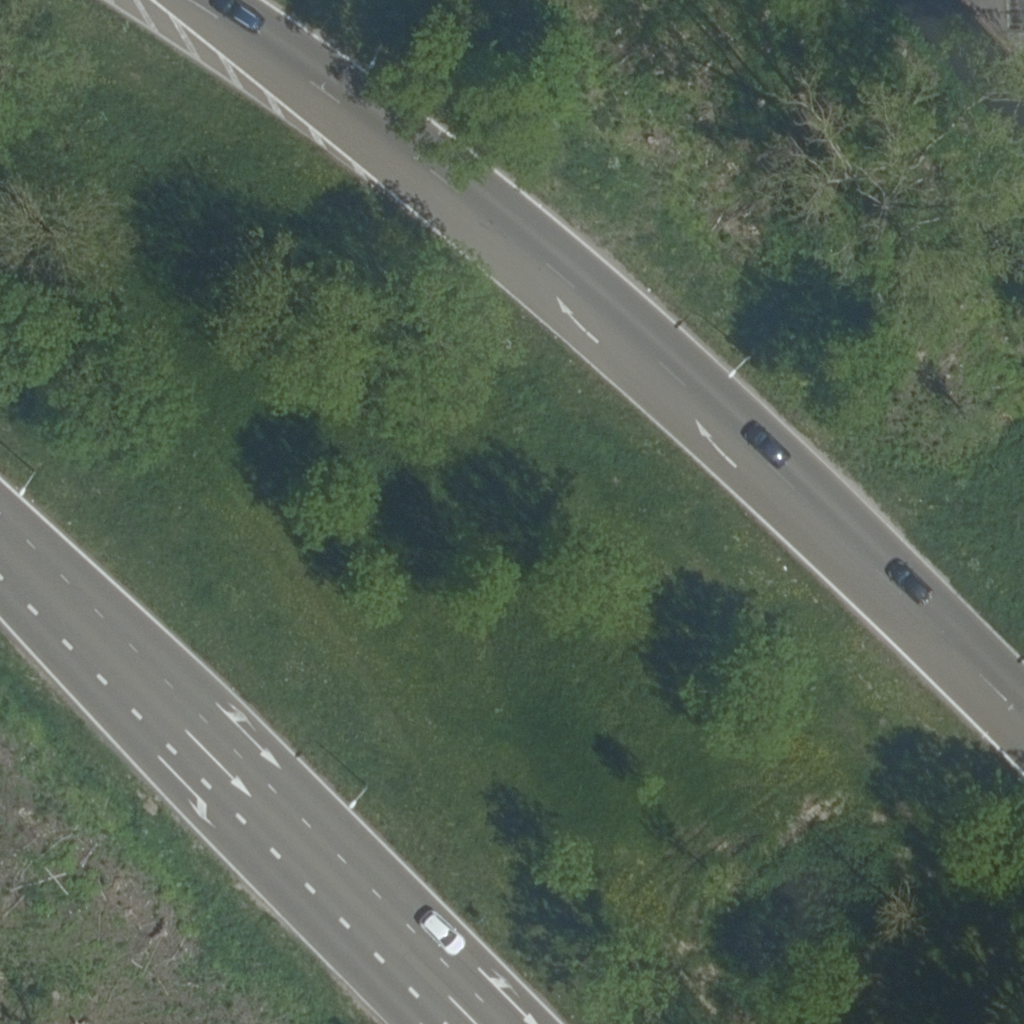

In [ ]:
FastVisionModel.for_inference(model)

# Change idx to see different samples
idx = 234 # try different numbers: 0, 1, 2, 50, 100...

sample    = test_data[idx]
image     = sample["messages"][0]["content"][0]["image"]
# question  = sample["messages"][0]["content"][1]["text"]
question= "Describe the image."
gt_answer = sample["messages"][1]["content"][0]["text"]

print(f"Question  : {question}")
print(f"GT Answer : {gt_answer}")
print(f"\nModel output:")

messages = [
    {
        "role": "system",
        "content": "You are a helpful VQA assistant for aerial images, DONT ANSWER IN ONE WORD, GIVE BRIEF EXPLANATION AS WELL."
    },
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": f"{question}, Also give explanation for your answer."}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    image, input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=32,
                   use_cache=True, temperature=1.0, do_sample=False)

# Display the image inline
display(image)